# Heart Failure Prediction

## Data Analysis

Let's start by importing important packages and loading in the dataset.

In [310]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [311]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


Let's start by graphing a few of the features (pie chart for anaemia and sex), and histograms for others.

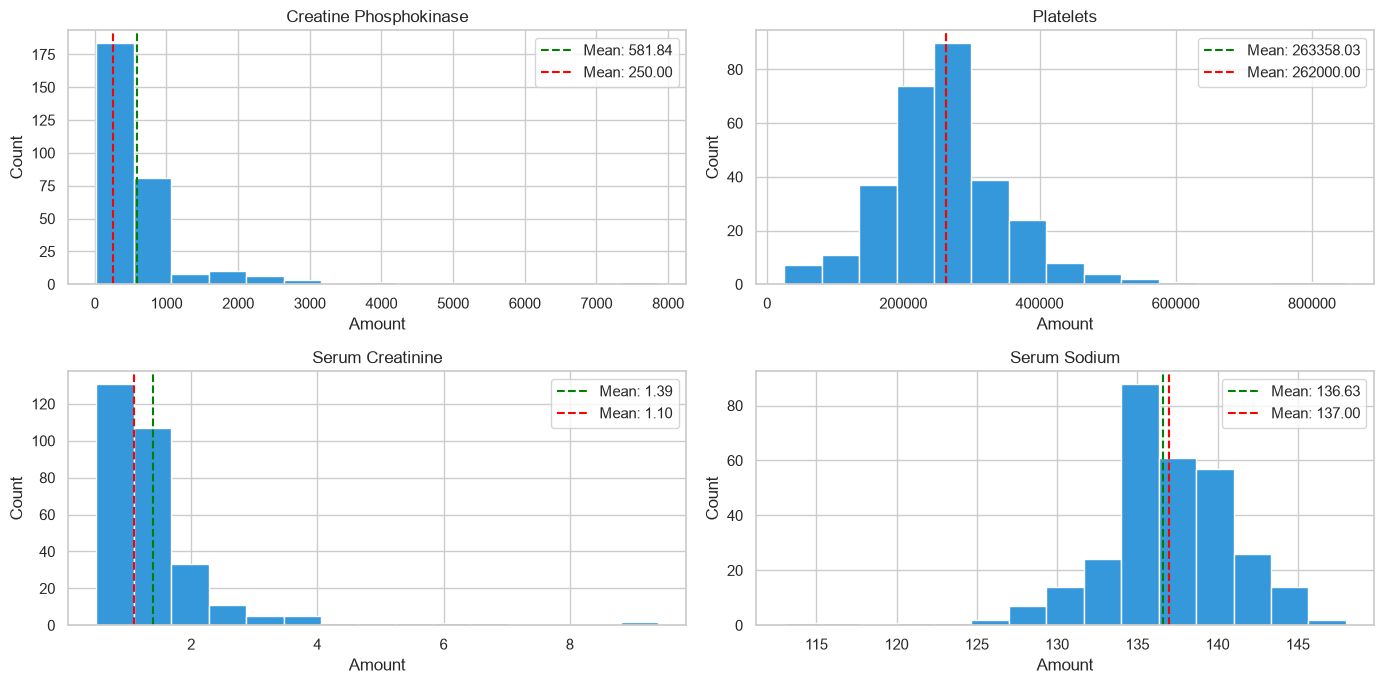

In [312]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 7))
flat_ax : list[plt.Axes] = axes.flatten()

categories = ["creatinine_phosphokinase", "platelets", "serum_creatinine", "serum_sodium"]
name = ["Creatine Phosphokinase", "Platelets", "Serum Creatinine", "Serum Sodium"]

for i, val in enumerate(categories):
    flat_ax[i].set_title(name[i])
    flat_ax[i].set_xlabel("Amount")
    flat_ax[i].set_ylabel("Count")

    flat_ax[i].hist(x=df[val], bins=15, edgecolor='white', color="#3498db")
    flat_ax[i].axvline(df[val].mean(), linestyle="--", label=f"Mean: {df[val].mean():.2f}", color="green")
    flat_ax[i].axvline(df[val].median(), linestyle="--", label=f"Mean: {df[val].median():.2f}", color="red")

    flat_ax[i].legend()

plt.tight_layout()
plt.show()

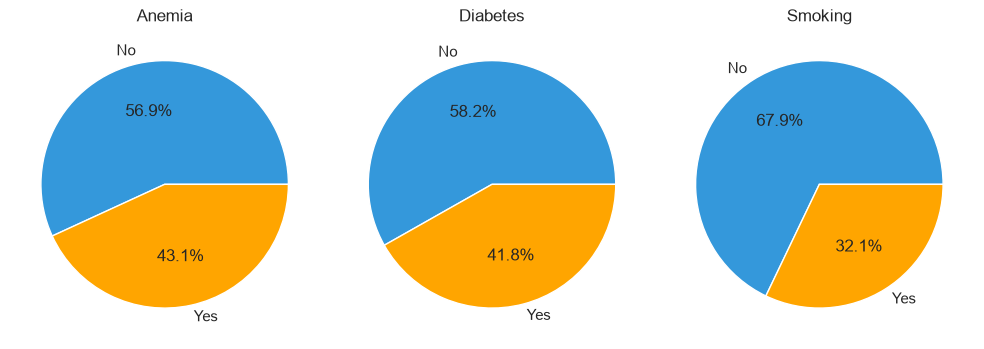

In [313]:
fig: plt.Figure
axes: list[plt.Axes]
fig, axes = plt.subplots(ncols=3, figsize=(10, 4))

anaemia_val_counts = df["anaemia"].value_counts()
axes[0].set_title("Anemia")
axes[0].pie(x=anaemia_val_counts, labels=["No", "Yes"], autopct="%1.1f%%", colors=["#3498db", "orange"])

diabetes_val_counts = df["diabetes"].value_counts()
axes[1].set_title("Diabetes")
axes[1].pie(x=diabetes_val_counts, labels=["No", "Yes"], autopct="%1.1f%%", colors=["#3498db", "orange"])

smoking_val_counts = df["smoking"].value_counts()
axes[2].set_title("Smoking")
axes[2].pie(x=smoking_val_counts, labels=["No", "Yes"], autopct="%1.1f%%", colors=["#3498db", "orange"])

plt.tight_layout()
plt.show()

/var/folders/bc/1q84krsx5vgcsc01l1rp77_r0000gn/T/ipykernel_9795/1018134044.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([""])


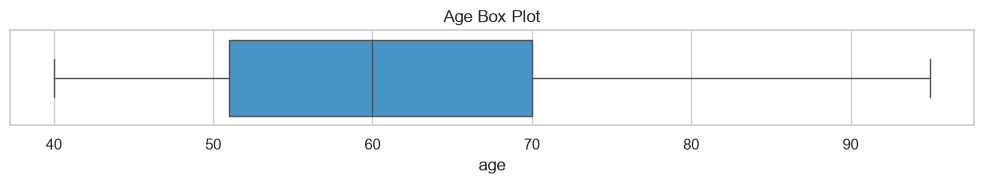

In [314]:
fig, ax = plt.subplots(figsize=(10, 2))

ax.set_title("Age Box Plot")
sns.boxplot(ax=ax, data=df, x="age", color="#3498db")
ax.set_yticklabels([""])

plt.tight_layout()
plt.show()

Overall death rate bar chart, and then death rate by age. 

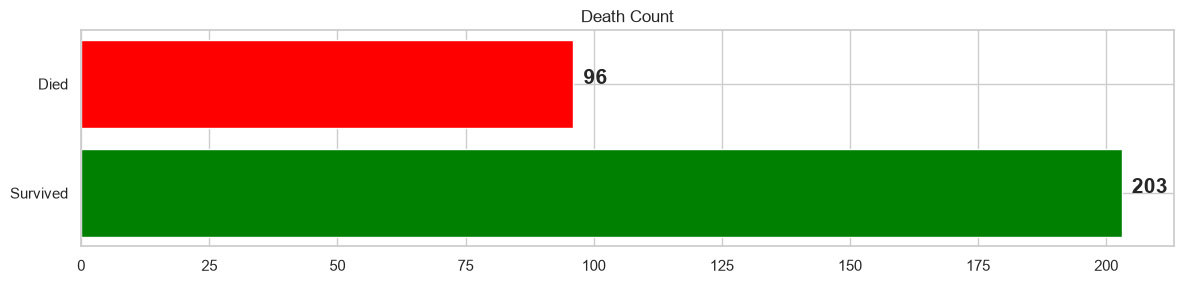

In [315]:
fig, ax = plt.subplots(figsize=(12, 3))

ax.set_title("Death Count")
death_counts = df["DEATH_EVENT"].value_counts()

ax.barh(["Survived", "Died"], death_counts.values, color=["Green", "Red"])

for i, val in enumerate(death_counts):
    ax.text(x=val+2, y=i, s=val, fontweight="bold", fontsize=15)

plt.tight_layout()
plt.show()

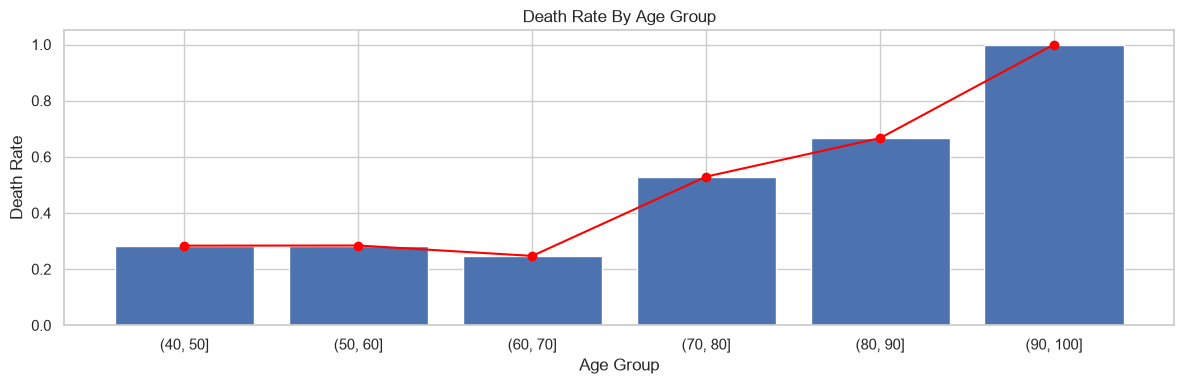

In [316]:
rate_by_age = df.groupby(pd.cut(df["age"], bins=[40, 50, 60, 70, 80, 90, 100]))["DEATH_EVENT"].mean()

fig, ax = plt.subplots(figsize=(12, 4))

ax.set_title("Death Rate By Age Group")

ax.bar(rate_by_age.index.astype(str), rate_by_age.values)
ax.plot(rate_by_age.index.astype(str), rate_by_age.values, marker='o', color="red")

ax.set_xlabel("Age Group")
ax.set_ylabel("Death Rate")

plt.tight_layout()
plt.show()

Comparing Anemia, Diabetes, and Smoking versus Death Rate

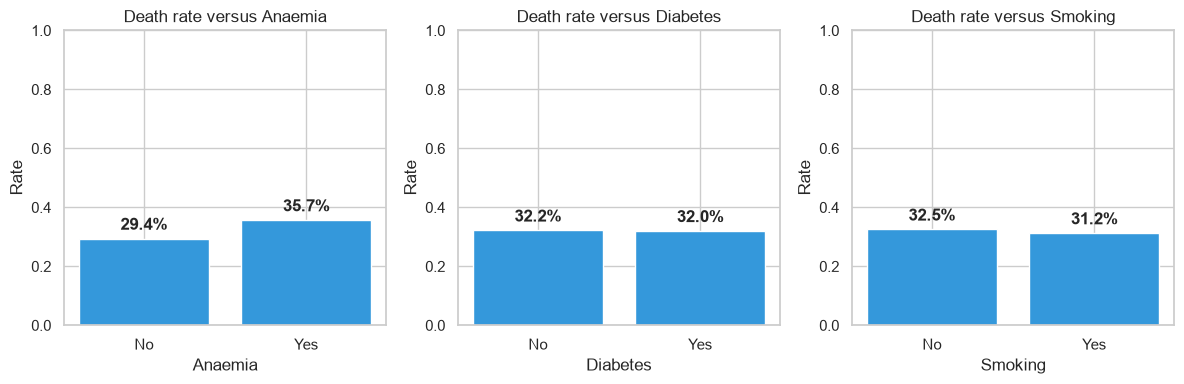

In [317]:
fig : plt.Figure
axes : list[plt.Axes]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

compare_categories = ["anaemia", "diabetes", "smoking"]
names = ["Anaemia", "Diabetes", "Smoking"]

for i, val in enumerate(compare_categories):
    axes[i].set_title("Death rate versus " + names[i])
    axes[i].set_ylabel("Rate")
    axes[i].set_xlabel(names[i])

    rate_counts = df.groupby(compare_categories[i])["DEATH_EVENT"].mean()
    
    axes[i].bar(["No", "Yes"], rate_counts.values, color="#3498db")
    axes[i].set_ylim(0, 1)

    for j, v in enumerate(rate_counts):
        axes[i].text(x=j, y=v + 0.03, s=f"{v:.1%}", ha="center", fontweight="bold")


plt.tight_layout()
plt.show()

Lastly, let's create a correlation map of all the different features.

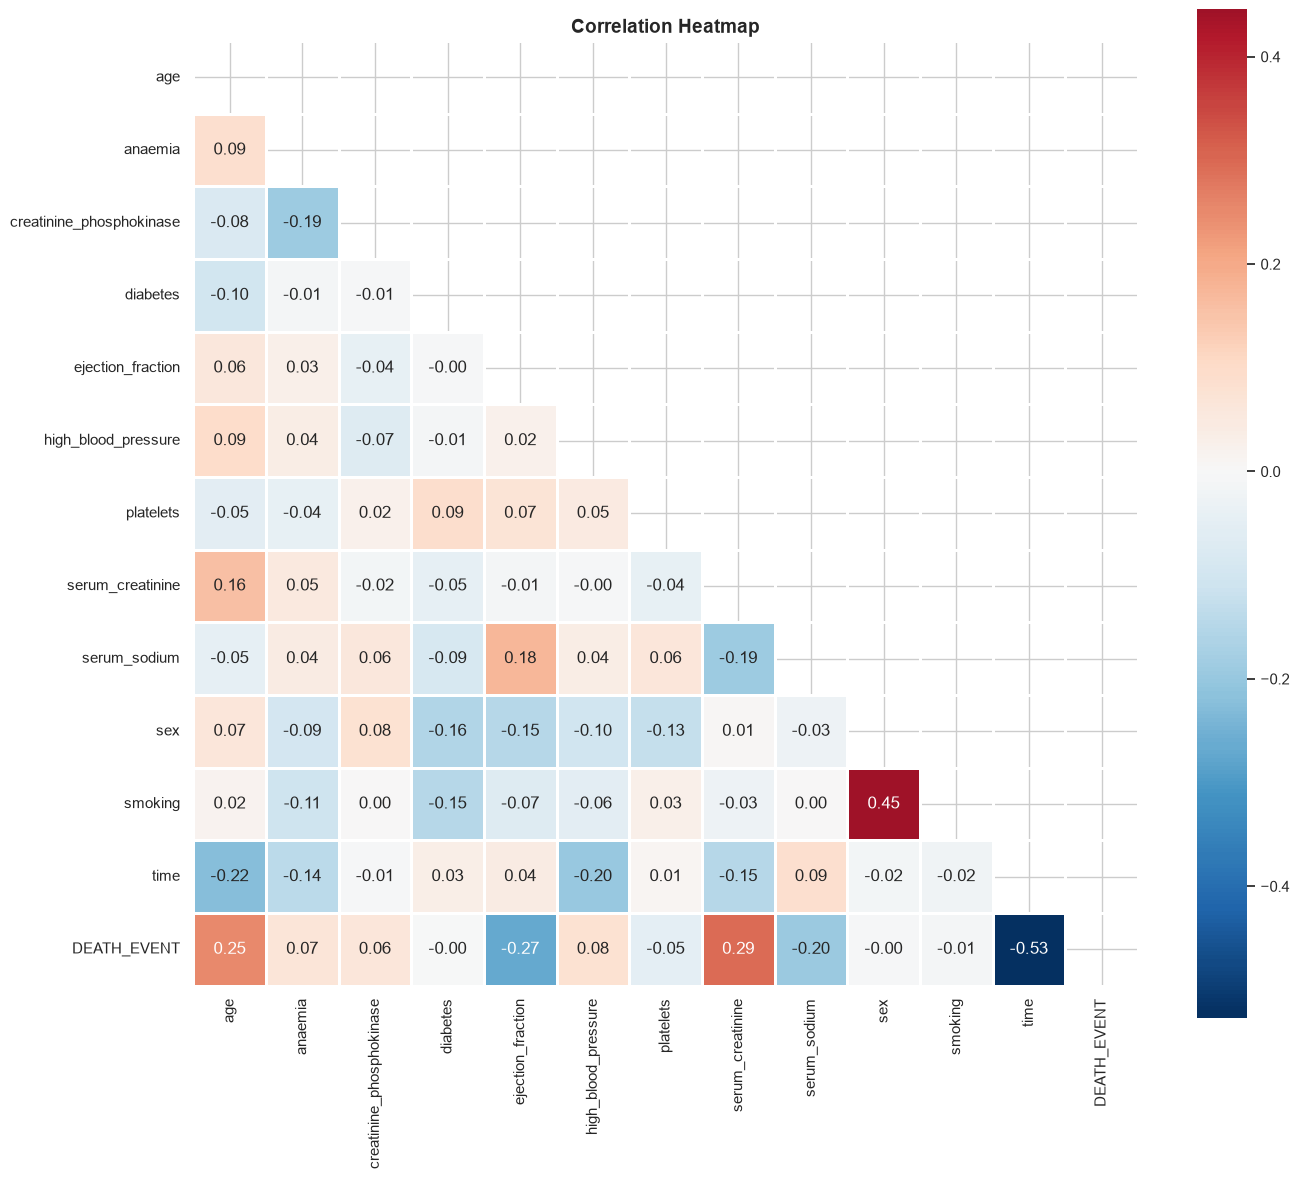

In [318]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = df.corr() # uses pearson's correlation coefficient to determine the correlation between two variables
mask=np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=1, ax=ax)

ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<Axes: xlabel='time', ylabel='age'>

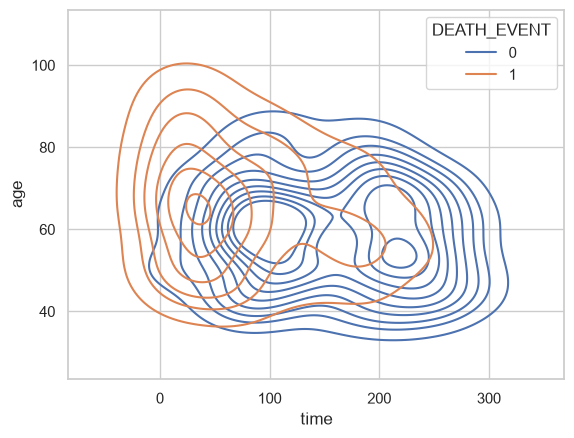

In [319]:
sns.kdeplot(x=df["time"], y=df["age"], hue=df["DEATH_EVENT"])

## Creating the Model

Import sci-kit learn and classification models.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, TunedThresholdClassifierCV
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, make_scorer, confusion_matrix

def evaluate_model(y_true, y_pred):
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}")
    print(f"Recall: {recall_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"F1: {f1_score(y_true, y_pred):.3f}")


def create_conf_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Alive", "Died"],
        yticklabels=["Alive", "Died"],
    )

    plt.title(f"Confusion Matrix — Logistic Regression")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

### Logistic Regression

In [321]:
X = df.drop(columns=["DEATH_EVENT"]).to_numpy()
y = df["DEATH_EVENT"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

logistic_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

logistic_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


Accuracy: 0.817
Recall: 0.579
Precision: 0.786
F1: 0.667
[[38  3]
 [ 8 11]]


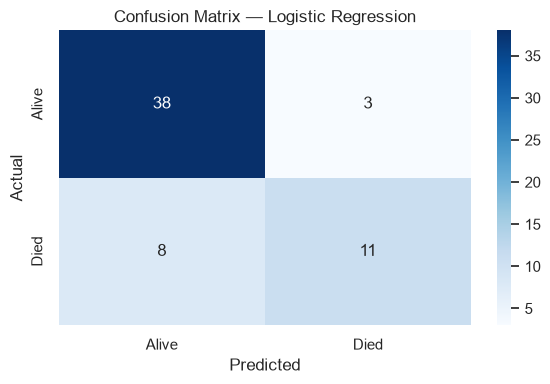

In [322]:
y_pred = logistic_pipe.predict(X_test)

evaluate_model(y_test, y_pred)
create_conf_matrix(y_test, y_pred)

Now, we can use grid-search CV to find the best regularization constant C for logistic regression.

Accuracy: 0.817
Recall: 0.579
Precision: 0.786
F1: 0.667
[[38  3]
 [ 8 11]]


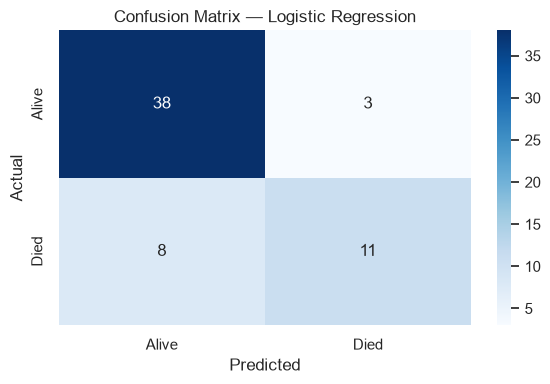

In [323]:
log_grid = GridSearchCV(
    estimator=logistic_pipe,
    param_grid=[
        {
            "model__C": np.logspace(-4, 3, 15),
            "model__class_weight": [None, "balanced"],
        }
    ],
    cv=5, # by default this is a StratifiedKFold
    refit="f1"
)

log_grid.fit(X_train, y_train)
best_log = log_grid.best_estimator_

y_pred = best_log.predict(X_test)

evaluate_model(y_test, y_pred)
create_conf_matrix(y_test, y_pred)

### Support Vector Machines (SVM)

In [324]:
pipe_svc = Pipeline([
    ("scalar", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

pipe_svc.fit(X_train, y_train)

y_pred = pipe_svc.predict(X_test)

svc_grid = GridSearchCV(
    estimator=pipe_svc,
    param_grid=[
        {"model__kernel": ["linear", "poly", "rbf", "sigmoid"]}
    ],
    cv=5,
    refit="f1"
)

svc_grid.fit(X_train, y_train)

best_svc = svc_grid.best_estimator_

y_pred = best_svc.predict(X_test)

evaluate_model(y_test, y_pred)
confusion_matrix(y_test, y_pred)

Accuracy: 0.783
Recall: 0.421
Precision: 0.800
F1: 0.552


array([[39,  2],
       [11,  8]])

### Gradient Boosting

In [325]:
pipe_boost = Pipeline([
    ("scalar", StandardScaler()),
    ("model", GradientBoostingClassifier())
])

boost_grid = GridSearchCV(
    estimator=pipe_boost,
    param_grid=[
        {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [1, 2, 3],
            "model__min_samples_leaf": [5, 10, 20],
            "model__subsample": [0.7, 0.9, 1.0]
        }
    ],
    cv=5,
    n_jobs=-1,
    refit="f1"
)

boost_grid.fit(X_train, y_train)

best_boost = boost_grid.best_estimator_

print(boost_grid.best_params_)
y_pred = best_boost.predict(X_test)

evaluate_model(y_test, y_pred)
confusion_matrix(y_test, y_pred)

{'model__learning_rate': 0.05, 'model__max_depth': 1, 'model__min_samples_leaf': 5, 'model__n_estimators': 100, 'model__subsample': 0.7}
Accuracy: 0.817
Recall: 0.474
Precision: 0.900
F1: 0.621


array([[40,  1],
       [10,  9]])

### KNN

In [ ]:
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_grid = GridSearchCV(
    estimator=pipe_knn,
    param_grid=[{
        "model__n_neighbors": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
    }],
    cv=5,
    refit=""
)

### Threshold Tuning for Logistic Regression

Accuracy: 0.817
Recall: 0.579
Precision: 0.786
F1: 0.667
[[38  3]
 [ 8 11]]


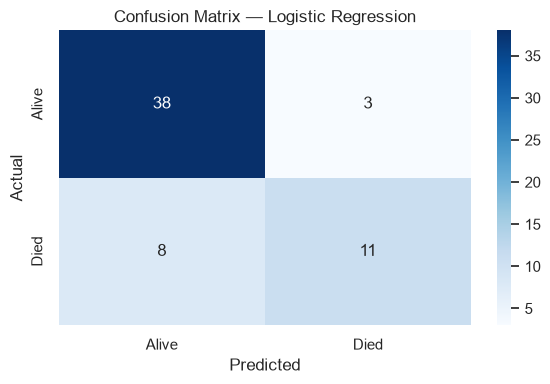

In [326]:
threshold_model = TunedThresholdClassifierCV(
    estimator=best_log,
    scoring="f1",
    cv=5,
    refit=True
)

threshold_model.fit(X_train, y_train)

y_pred = threshold_model.predict(X_test)

evaluate_model(y_test, y_pred)

create_conf_matrix(y_test, y_pred)